# CSSP Summer/Winter School - Example Notebook

This notebook investigates whether the anomalously hot austral summer of 2024 (December–February) in the state of **São Paulo, Brazil** was made more likely by human-caused climate change.

The climate variable of interest is the **Wet Bulb Globe Temperature (WBGT)**, a composite heat-stress index that integrates dry-bulb temperature, humidity, wind speed, and solar radiation. WBGT is widely used in occupational health and sports medicine to assess heat stress risk.

---

### What is Extreme Event Attribution?

Attribution science asks: **"Was this extreme event made more (or less) likely by human-caused climate change?"**

We compare two counterfactual worlds using large climate model ensembles:
- **ALL forcing** (factual world): includes all forcings — greenhouse gases, aerosols, natural variability
- **NAT forcing** (counterfactual world): includes only natural forcings — volcanic, solar

The key metrics we compute are:

**Probability Ratio (PR):**  
$$PR = \frac{P_{\text{ALL}}(X \geq x_0)}{P_{\text{NAT}}(X \geq x_0)}$$

A PR > 1 means the event became *more likely* in the world with human influence.

**Fraction of Attributable Risk (FAR):**  
$$FAR = 1 - \frac{1}{PR}$$

FAR represents the fraction of the event's probability that can be attributed to human influence.

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# climattr — the attribution package we will use throughout
import climattr as eea

# scipy for distribution fitting
from scipy import stats

print("✅ All imports successful")

✅ All imports successful


In [2]:
# ── File paths ─────────────────────────────────────────────────────────────
# Adjust these paths to point to your data files.

OBS_PATH  = '/gws/ssde/j25a/cpdn_nonnerc/aaim/era5/wbgt/wbgt-daily_max-*.nc'                                                                          # ERA5 or station-based observations
ALL_PATH  = '/gws/ssde/j25a/cpdn_nonnerc/aaim/HadGEM3-A-N216/historicalExt/wbgt/wbgt_day_HadGEM3-A-N216_historicalExt_*_20220101-20241230.nc'         # ALL-forcing model ensemble
NAT_PATH  = '/gws/ssde/j25a/cpdn_nonnerc/aaim/HadGEM3-A-N216/historicalNatExt/wbgt/wbgt_day_HadGEM3-A-N216_historicalNatExt_*_20220101-20241230.nc'   # NAT-forcing (natural-only) ensemble
HIST_PATH = '/gws/ssde/j25a/cpdn_nonnerc/aaim/HadGEM3-A-N216/historical/wbgt/wbgt_day_HadGEM3-A-N216_historical_*_19600101-20131230.nc' 

# Geographic bounds for the state of São Paulo
SAO_PAULO_BOX = {
    'lon_min': -53.1, 'lon_max': -44.2,
    'lat_min': -25.3, 'lat_max': -19.8,
}

# Reference period for climatology
CLIM_PERIOD = [1980, 2010]

# Event: DJF 2024 (Dec 2023 + Jan 2024 + Feb 2024)
EVENT_YEAR   = 2024
SUMMER_MONTHS = [12, 1, 2]   # DJF — austral summer

---
## Section 1 — Loading Pre-computed Data

We load the data directly and extract austral summer (DJF) annual mean for attribution analysis.

The `summer_annual_mean` helper below selects DJF months and returns the annual mean, labelling each season by its January year.

In [3]:
def summer_annual_mean(da, summer_months=None):
    """
    Return the annual mean of a DataArray over austral summer (DJF).

    Parameters
    ----------
    da : xr.DataArray
    summer_months : list of int, default [12, 1, 2]
        Months to include in the summer season.

    Returns
    -------
    xr.DataArray
        Annual-mean WBGT, indexed by year.

    Notes
    -----
    Austral summer spans two calendar years (Dec of year N, Jan–Feb of year N+1).
    December is assigned to the following year so each DJF season is kept together
    (e.g. Dec 2023 + Jan 2024 + Feb 2024 → year label 2024).
    """
    if summer_months is None:
        summer_months = [12, 1, 2]

    da_summer = da.sel(time=da['time'].dt.month.isin(summer_months))
    year_label = da_summer['time'].dt.year.where(
        da_summer['time'].dt.month != 12,
        da_summer['time'].dt.year + 1
    )
    return da_summer.groupby(year_label).mean(dim='time').rename({'year': 'time'})


print("✅ Helper functions defined")

✅ Helper functions defined


In [4]:
# ── Load pre-computed WBGT datasets ────────────────────────────────────────
print("Loading datasets...")
ds_obs = xr.open_mfdataset(OBS_PATH).rename({'valid_time': 'time'})
ds_all = xr.open_mfdataset(ALL_PATH, concat_dim='ens', combine='nested')
ds_nat = xr.open_mfdataset(NAT_PATH, concat_dim='ens', combine='nested')
ds_hist = xr.open_mfdataset(HIST_PATH, concat_dim='ens', combine='nested')

wbgt_obs  = ds_obs['wbgt']
wbgt_hist = ds_hist['wbgt']
wbgt_all  = ds_all['wbgt']
wbgt_nat  = ds_nat['wbgt']

print("Observations shape         :", wbgt_obs.shape)
print("Historical ALL forcing shape:", wbgt_hist.shape)
print("ALL forcing shape          :", wbgt_all.shape)
print("NAT forcing shape          :", wbgt_nat.shape)

Loading datasets...
Observations shape         : (16771, 157, 161)
Historical ALL forcing shape: (15, 19724, 70, 48)
ALL forcing shape          : (525, 1096, 70, 48)
NAT forcing shape          : (524, 1096, 70, 48)


---
## Section 2 — Spatial Masking

We isolate the **state of São Paulo** in two ways:

1. **Bounding box** — a rectangular selection covering the state's full extent (~44°W–53°W, ~20°S–25°S)
2. **Shapefile mask** *(recommended)* — the precise state boundary polygon from IBGE, which avoids including ocean and neighbouring states

`climattr`'s `filter.filter_area` function handles both approaches and returns a spatially averaged time series ready for attribution analysis.

> **📌 Geographic context:** The state of São Paulo spans roughly 248,000 km² across subtropical southeast Brazil. Shapefiles are freely available from IBGE (see Option B below).

Applying spatial mask...


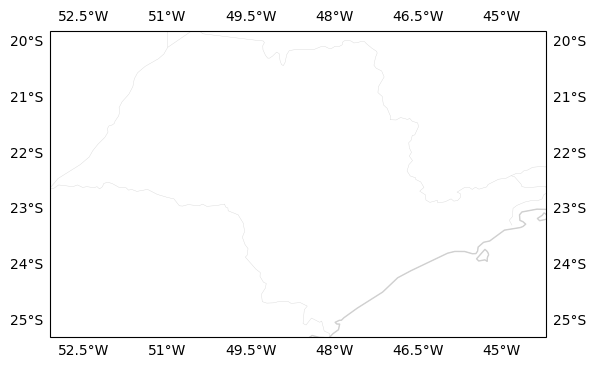

Spatial averaging complete
Obs   time range: ['1979-01-01T00:00:00.000000000' '2024-11-30T00:00:00.000000000']
HIST  time range: ['1960-01-01T12:00:00.000000000' '2013-12-31T12:00:00.000000000']
ALL   time range: ['2022-01-01T12:00:00.000000000' '2024-12-31T12:00:00.000000000']
NAT   time range: ['2022-01-01T12:00:00.000000000' '2024-12-31T12:00:00.000000000']


In [5]:
# ── Option A: Bounding box selection ───────────────────────────────────────
box = [
    SAO_PAULO_BOX['lon_min'], SAO_PAULO_BOX['lon_max'],
    SAO_PAULO_BOX['lat_min'], SAO_PAULO_BOX['lat_max'],
]

# climattr's filter_area returns a spatially averaged DataArray
# plot_area=True shows the selected region on a map
print("Applying spatial mask...")
obs_sp  = eea.filter.filter_area(wbgt_obs.to_dataset(), box=box, plot_area=True)
all_sp  = eea.filter.filter_area(wbgt_all.to_dataset(), box=box)
nat_sp  = eea.filter.filter_area(wbgt_nat.to_dataset(), box=box)
hist_sp = eea.filter.filter_area(wbgt_hist.to_dataset(), box=box)

print("Spatial averaging complete")
print(f"Obs   time range: {str(obs_sp['wbgt']['time'].values[[0, -1]])}")
print(f"HIST  time range: {str(hist_sp['wbgt']['time'].values[[0, -1]])}")
print(f"ALL   time range: {str(all_sp['wbgt']['time'].values[[0, -1]])}")
print(f"NAT   time range: {str(nat_sp['wbgt']['time'].values[[0, -1]])}")

In [6]:
# ── Option B (optional): Shapefile mask ────────────────────────────────────
# If you have a shapefile for the state of São Paulo, use this instead:
#
# SHAPEFILE = 'data/sao_paulo_state.shp'
# obs_sp = eea.spatial.filter_area(wbgt_obs.to_dataset(), mask=SHAPEFILE, plot_area=True)
# all_sp = eea.spatial.filter_area(wbgt_all.to_dataset(), mask=SHAPEFILE)
# nat_sp = eea.spatial.filter_area(wbgt_nat.to_dataset(), mask=SHAPEFILE)
#
# Shapefiles for Brazilian states are freely available from IBGE:
# https://www.ibge.gov.br/geociencias/organizacao-do-territorio/malhas-territoriais
print("Shapefile masking commented out — remove comments above to use it")

Shapefile masking commented out — remove comments above to use it


In [7]:
# This cell takes a little while to run ...

# ── Compute annual DJF means and spatial average ───────────────────────────
# mean(dim=['latitude','longitude']) collapses the spatial dims and skips NaN
# cells introduced by the mask, producing clean 1-D (year,) time series.
obs_djf  = summer_annual_mean(obs_sp['wbgt']).mean(dim=['latitude', 'longitude']).load()
hist_djf = summer_annual_mean(hist_sp['wbgt']).mean(dim=['lat', 'lon']).load()
all_djf  = summer_annual_mean(all_sp['wbgt']).mean(dim=['latitude', 'longitude']).load()
nat_djf  = summer_annual_mean(nat_sp['wbgt']).mean(dim=['latitude', 'longitude']).load()

# Event: observed DJF 2024 mean (Dec 2023 + Jan 2024 + Feb 2024)
event_2024 = float(obs_djf.sel(time=EVENT_YEAR))

# Event (model): DJF 2024 mean (Dec 2023 + Jan 2024 + Feb 2024)
all_djf = all_djf.sel(time=EVENT_YEAR)
nat_djf = nat_djf.sel(time=EVENT_YEAR)

print("Annual DJF means:")
print(f"  Obs  — {len(obs_djf)} years, mean = {float(obs_djf.mean()):.2f}°C")
print(f"  HIST — {len(hist_djf)} years, mean = {float(hist_djf.mean()):.2f}°C")
print(f"  ALL  — {len(all_djf)} ensembles, mean = {float(all_djf.mean()):.2f}°C")
print(f"  NAT  — {len(nat_djf)} ensembles, mean = {float(nat_djf.mean()):.2f}°C")
print()
print(f"Event — DJF {EVENT_YEAR} mean WBGT (observed): {event_2024:.2f}°C")

Annual DJF means:
  Obs  — 46 years, mean = 27.52°C
  HIST — 15 years, mean = 26.42°C
  ALL  — 525 ensembles, mean = 27.30°C
  NAT  — 524 ensembles, mean = 25.95°C

Event — DJF 2024 mean WBGT (observed): 28.41°C


In [11]:
# ── Align obs and hist to the same year range ──────────────────────────────
common_years = np.intersect1d(obs_djf.time.values, hist_djf.time.values)
obs_djf_val  = obs_djf.sel(time=common_years)
hist_djf_val = hist_djf.sel(time=common_years)

print(f"Common     : {common_years[0]}–{common_years[-1]}  ({len(common_years)} years)")

Common     : 1979–2014  (36 years)


---
## Section 3 — Event Characterization

Before attributing the DJF 2024 event to climate change, we first characterise it in the context of the observed record: How unusual was it? What is its estimated return period?

Two plots from `climattr.exploratory` help answer this:

1. **Time series** — the full observational record
2. **Return period plot** — how often an event of this magnitude is expected to occur based on a fitted distribution

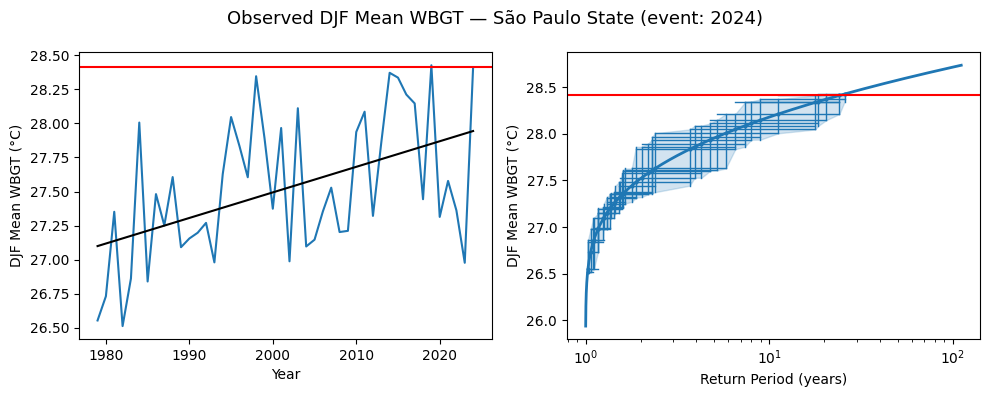

In [17]:
# ── Event characterisation — observations only ─────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

eea.exploratory.timeseries_plot(ax1, obs_djf, highlight_year=None, percentiles=None)
eea.exploratory.rp_plot(ax2, obs_djf, stats.norm, highlight_year=None)

ax1.set_xlabel('Year')
ax1.set_ylabel('DJF Mean WBGT (°C)')
ax2.set_xlabel('Return Period (years)')
ax2.set_ylabel('DJF Mean WBGT (°C)')

ax1.axhline(event_2024, color='red')
ax2.axhline(event_2024, color='red')

fig.suptitle(f'Observed DJF Mean WBGT — São Paulo State (event: {EVENT_YEAR})', fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 4 — Model Validation & Bias Correction

Before running attribution analysis, we check that the climate model reproduces observed statistics in the selected region. We use the **historical ALL-forcing simulation** (`hist`) for this comparison — it covers the period 1960–2014 and includes all historical forcings, so it should be comparable to the observations over the same years.

If a systematic bias is found, a **bias correction** can be applied to shift the ALL and NAT distributions before computing attribution metrics.

We use two diagnostic plots provided by `climattr`:

1. **Histogram + fitted distribution** — compares the shape of the observed and historical-model distributions
2. **Quantile-Quantile (QQ) plot** — shows whether model quantiles match observations across the full distribution

> **What to look for:**
> - Histogram: Do the distribution peaks and spreads align?
> - QQ plot: Do points fall close to the 1:1 diagonal? A systematic offset suggests an additive bias; a slope deviation suggests a scaling bias.
> - Pay particular attention to the upper tail (high WBGT values) — this is where attribution is most sensitive.

In [18]:
# ── Choose a distribution for fitting ──────────────────────────────────────
# We start with Normal for simplicity; see Section 4 for GEV.
fit_function = stats.norm

print("Distribution selected:", fit_function.name)

Distribution selected: norm


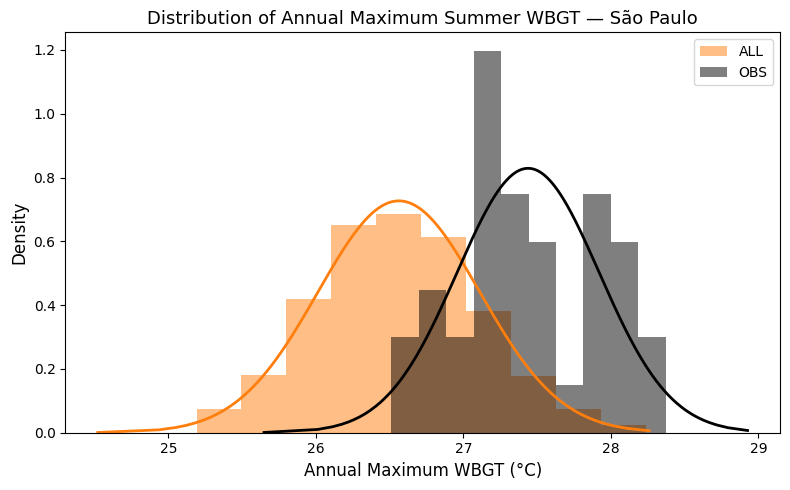

In [19]:
# ── Validation: Histogram plot ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

eea.validation.histogram_plot(
    ax,
    obs=obs_djf_val,
    all=hist_djf_val,
    fit_function=fit_function
)

ax.set_xlabel('Annual Maximum WBGT (°C)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Distribution of Annual Maximum Summer WBGT — São Paulo', fontsize=13)
plt.tight_layout()
plt.show()

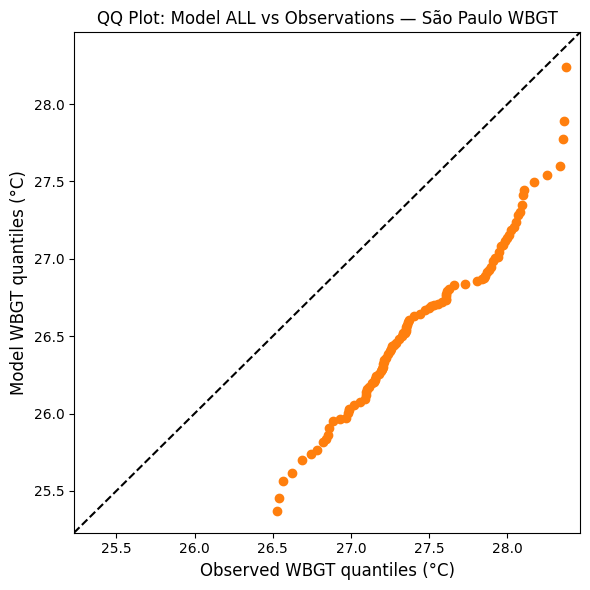

In [20]:
# ── Validation: QQ plot ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))

eea.validation.qq_plot(
    ax,
    obs=obs_djf_val,
    all=hist_djf_val
)

ax.set_xlabel('Observed WBGT quantiles (°C)', fontsize=12)
ax.set_ylabel('Model WBGT quantiles (°C)', fontsize=12)
ax.set_title('QQ Plot: Model ALL vs Observations — São Paulo WBGT', fontsize=12)
plt.tight_layout()
plt.show()

### Interpreting Validation Plots

Look at the two plots above and think about these questions:

1. Is the model mean higher or lower than observations?
2. Does the model capture the spread (variance) of observations?
3. In the QQ plot, does the model overestimate or underestimate extreme values?
4. Do you need any type of bias correction? Why or why not?

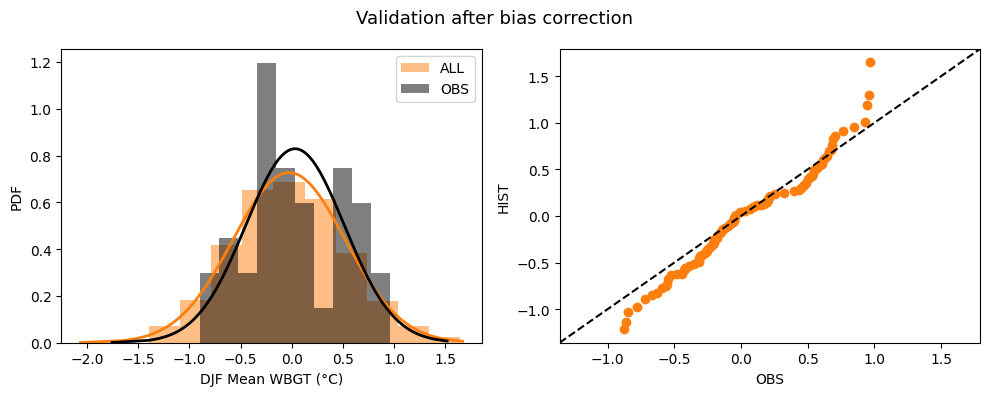

✅ Bias correction applied to obs, ALL, and NAT
   Event (DJF 2024) in corrected space: 1.00°C


In [26]:
# ── Bias correction — additive scaling ─────────────────────────────────────
# Step 1: scale hist and obs against their own reference period climatology
hist_djf_bc = eea.correction.scaling(hist_djf, hist_djf, CLIM_PERIOD[0], CLIM_PERIOD[1], method='add')
obs_djf_bc  = eea.correction.scaling(obs_djf,  obs_djf,  CLIM_PERIOD[0], CLIM_PERIOD[1], method='add')

obs_djf_bc_val  = obs_djf_bc.sel(time=common_years)
hist_djf_bc_val = hist_djf_bc.sel(time=common_years)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

eea.validation.histogram_plot(ax1, obs_djf_bc_val, hist_djf_bc_val, fit_function)
eea.validation.qq_plot(ax2, obs_djf_bc_val, hist_djf_bc_val)

ax1.set_xlabel('DJF Mean WBGT (°C)')
ax1.set_ylabel('PDF')
ax2.set_xlabel('OBS')
ax2.set_ylabel('HIST')
fig.suptitle(
    f'Validation after bias correction',
    fontsize=13
)
plt.tight_layout()
plt.show()

# Step 3: apply the same scaling to ALL and NAT
all_djf_bc = eea.correction.scaling(all_djf, hist_djf, 1980, 2010, method='add')
nat_djf_bc = eea.correction.scaling(nat_djf, hist_djf, 1980, 2010, method='add')

# Update all working variables and recompute the event threshold in corrected space
obs_djf = obs_djf_bc 
all_djf = all_djf_bc
nat_djf = nat_djf_bc
event_2024 = float(obs_djf.sel(time=EVENT_YEAR))

# Define threshold value
threshold = event_2024

print(f"✅ Bias correction applied to obs, ALL, and NAT")
print(f"   Event (DJF {EVENT_YEAR}) in corrected space: {event_2024:.2f}°C")

---
## Section 5 — Fitting a Statistical Distribution

Attribution analysis requires fitting a probability distribution to the data so we can estimate probabilities for any threshold — not just values observed in the finite sample.

### Distribution choice for DJF means

Because we are working with **seasonal means** (rather than block maxima), the **Normal distribution** is the natural first choice — seasonal averages tend toward normality by the central limit theorem. A **Gamma** distribution can be used as a sensitivity check for right-skewed data.
A **GEV** would be a good option for block maxima, such as the maximum daily precipitation or temperature.

In [22]:
# ── Fit Normal distributions to ALL and NAT ensembles ──────────────────────
params_all = stats.norm.fit(all_djf.values)
params_nat = stats.norm.fit(nat_djf.values)

loc_all, scale_all = params_all
loc_nat, scale_nat = params_nat

print("Normal fit — ALL forcing:")
print(f"  location (μ) = {loc_all:.2f}°C  |  scale (σ) = {scale_all:.2f}°C")
print()
print("Normal fit — NAT forcing:")
print(f"  location (μ) = {loc_nat:.2f}°C  |  scale (σ) = {scale_nat:.2f}°C")
print()
print(f"Shift in location parameter (ALL - NAT): {loc_all - loc_nat:.2f}°C")
print("→ This is the anthropogenic shift in typical DJF mean WBGT")

Normal fit — ALL forcing:
  location (μ) = 0.71°C  |  scale (σ) = 0.49°C

Normal fit — NAT forcing:
  location (μ) = -0.64°C  |  scale (σ) = 0.51°C

Shift in location parameter (ALL - NAT): 1.36°C
→ This is the anthropogenic shift in typical DJF mean WBGT


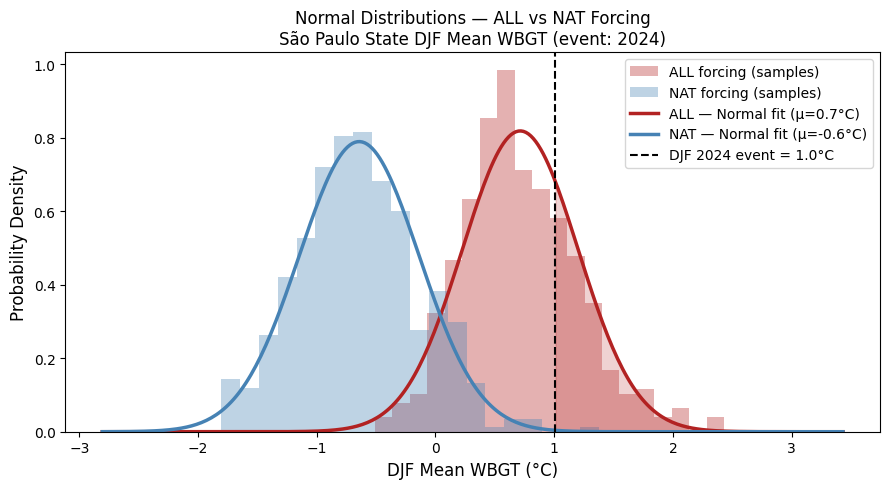

In [23]:
# ── Visualise fitted distributions ─────────────────────────────────────────
x = np.linspace(
    min(all_djf.values.min(), nat_djf.values.min()) - 1,
    max(all_djf.values.max(), nat_djf.values.max()) + 1,
    300
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(all_djf.values, bins=20, alpha=0.35, color='firebrick',
        density=True, label='ALL forcing (samples)')
ax.hist(nat_djf.values, bins=20, alpha=0.35, color='steelblue',
        density=True, label='NAT forcing (samples)')

ax.plot(x, stats.norm.pdf(x, *params_all), color='firebrick', lw=2.5,
        label=f'ALL — Normal fit (μ={loc_all:.1f}°C)')
ax.plot(x, stats.norm.pdf(x, *params_nat), color='steelblue', lw=2.5,
        label=f'NAT — Normal fit (μ={loc_nat:.1f}°C)')

ax.axvline(threshold, color='black', linestyle='--', lw=1.5,
           label=f'DJF {EVENT_YEAR} event = {threshold:.1f}°C')

x_exc = x[x >= threshold]
ax.fill_between(x_exc, stats.norm.pdf(x_exc, *params_all), alpha=0.2, color='firebrick')
ax.fill_between(x_exc, stats.norm.pdf(x_exc, *params_nat), alpha=0.2, color='steelblue')

ax.set_xlabel('DJF Mean WBGT (°C)', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title(f'Normal Distributions — ALL vs NAT Forcing\nSão Paulo State DJF Mean WBGT (event: {EVENT_YEAR})', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### Reading the Distribution Plot

1. The shaded areas represent the probability of exceeding the threshold. Which world (ALL or NAT) has higher exceedance probability?
2. Estimate visually: how much warmer is the ALL-forcing distribution compared to NAT-forcing?
3. Why do we use a threshold from *observations* rather than from the model itself?


---
## Section 6 — Attribution Metrics

We now compute the core attribution metrics using `climattr.attribution.attribution_metrics`.

The function computes PR and FAR with **bootstrap confidence intervals** to account for sampling uncertainty in the finite ensemble.

### Interpreting PR and FAR

| PR | Interpretation |
|----|----------------|
| PR = 0.5 | Event is 50% less likely due to climate change |
| PR = 1   | No change in likelihood — climate change had no effect |
| PR = 2   | Event is twice as likely due to climate change |
| PR = 5   | Event is 5× more likely |
| PR → ∞   | Event was essentially impossible without climate change |

| FAR | Interpretation |
|-----|----------------|
| FAR = 0 | None of the risk is attributable to climate change |
| FAR = 0.5 | Half the probability is attributable to climate change |
| FAR = 1 | All of the probability is attributable to climate change |

In [24]:
# ── Compute attribution metrics ────────────────────────────────────────────
print(f"Computing attribution for threshold = {threshold:.2f}°C...")

metrics = eea.attribution.attribution_metrics(
    all=all_djf,
    nat=nat_djf,
    fit_function=fit_function,   # Normal; swap for gev for GEV-based attribution
    thresh=threshold
)

print()
print("═" * 50)
print("  ATTRIBUTION RESULTS — São Paulo Summer WBGT")
print("═" * 50)
print(metrics)
print("═" * 50)

Computing attribution for threshold = 1.00°C...

══════════════════════════════════════════════════
  ATTRIBUTION RESULTS — São Paulo Summer WBGT
══════════════════════════════════════════════════
                 PR       FAR    RP_ALL       RP_NAT
value    498.464557  0.997994  3.620082  1821.128880
ci_inf   232.679071  0.995702  3.234110   871.936016
ci_sup  1222.219131  0.999182  4.191697  4378.201565
══════════════════════════════════════════════════


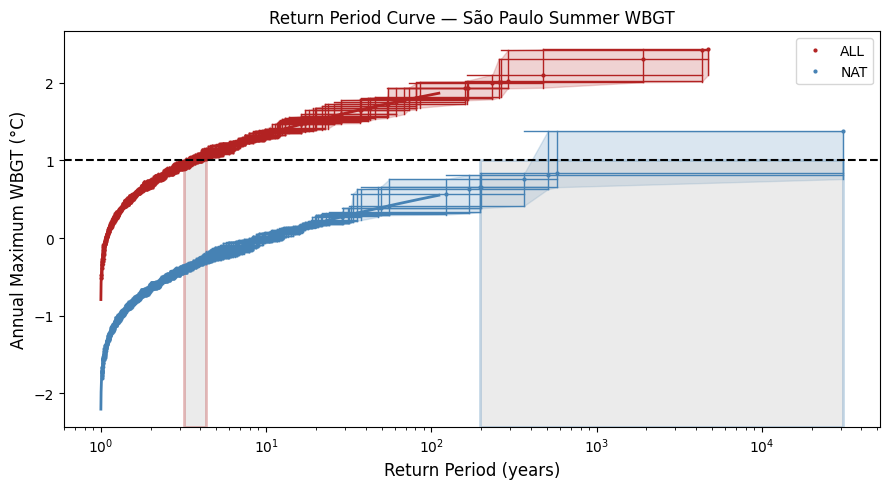

In [25]:
# ── Return Period plot ─────────────────────────────────────────────────────
# The return period plot shows how often events of different magnitudes occur
# in each world. A lower return period = more frequent event.

fig, ax = plt.subplots(figsize=(9, 5))

eea.attribution.rp_plot(
    ax,
    all=all_djf,
    nat=nat_djf,
    fit_function=fit_function,
    thresh=threshold,
    all_color='firebrick',
    nat_color='steelblue'
)

ax.set_xlabel('Return Period (years)', fontsize=12)
ax.set_ylabel('Annual Maximum WBGT (°C)', fontsize=12)
ax.set_title('Return Period Curve — São Paulo Summer WBGT', fontsize=12)
plt.tight_layout()
plt.show()

---
## Section 7 — Interpretation & Discussion

### Communicating attribution results

Attribution results must be communicated carefully. Key points:

- **PR and FAR are ensemble estimates** — they represent the behaviour of many model simulations, not a single event
- **Confidence intervals matter** — a PR of 2 with wide intervals (0.8–10) is very different from PR = 2 (1.5–3.0)
- **The threshold choice affects the result** — higher thresholds (rarer events) often show larger PRs
- **Model uncertainty is not fully captured** — results from a single model family (HadGEM3-A) may differ from a multi-model assessment

### Discussion questions

Based on your results, consider the following:

1. **What does your PR tell you?** Translate it into plain language: how many times more (or less) likely was DJF 2024 in a world with human influence compared to a world without?
2. **Is your confidence interval narrow or wide?** What does that imply about the robustness of the attribution signal?
3. **How would the result change if you used a higher or lower threshold?** Try shifting the threshold by ±0.5°C and re-running Section 6.
4. **How would you communicate this result to a policymaker?** Try writing one sentence suitable for a press release.